In [50]:
import torch 
import numpy as np
from d2l import torch as d2l
from torch import nn

In [51]:
class LinearRegression(d2l.Module):
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net=nn.LazyLinear(1)
        self.net.weight.data.normal_(0,0.01)
        self.net.bias.data.fill_(0)
@d2l.add_to_class(LinearRegression)
def forward(self,X):
    return self.net(X)
@d2l.add_to_class(LinearRegression)
def loss(self,y_hat,y):
    fn=nn.MSELoss()
    return fn(y_hat,y)
@d2l.add_to_class(LinearRegression)
def configure_optimizer(self):
    return torch.optim.SGD(self.parameter(),self.lr)

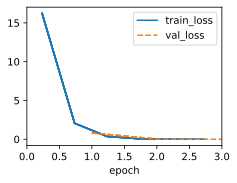

In [52]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [53]:
def add_to_class(Class):
    def wrapper(obj):
        setattr(Class,obj.__name__,obj)
    return wrapper

In [54]:
class RegressionData(d2l.DataModule):
    def __init__(self,w,b,num_train=1000,num_test=100,noise=0.01,batch_size=16):
        super().__init__()
        self.save_hyperparameters()
        n=num_train+num_test
        self.X=torch.randn(size=(n,len(w)))
        self.y=torch.matmul(self.X,self.w.reshape(-1,1))+self.b+noise*torch.randn(n,1)
@add_to_class(RegressionData)
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors=tuple(a[indices] for a in tensors)
    dataset=torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=train)
@add_to_class(RegressionData)
def get_dataloader(self,train):
    i =slice(0,self.num_train) if train else slice(self.num_train,self.num_train+self.num_test)
    return self.get_tensorloader((self.X,self.y),train,i)

In [55]:
class RegressionData1(d2l.DataModule):
    def __init__(self,w,b,noise=0.001,num_train=1000,num_test=100,batch_size=16):
        super().__init__()
        self.save_hyperparameters()
        n=self.num_train+self.num_test
        self.X=torch.randn((n,len(w)))
        self.y=torch.matmul(self.X,self.w.reshape(-1,1))+self.b+torch.randn((n,1))*noise
@add_to_class(RegressionData1)
def get_tensorloader(self,train,tensor,indices=slice(0,None),):
    tensor=tuple(a[indices] for a in tensor)
    dataset=torch.utils.data.TensorDataset(*tensor)
    dataloader=torch.utils.data.DataLoader(dataset,batch_size=self.batch_size,shuffle=train)
    return dataloader
@add_to_class(RegressionData1)
def get_dataloader(self,train):
    indices=slice(0,self.num_train) if train else (self.num_train,None)
    return self.get_tensorloader(True,(self.X,self.y),indices)

In [56]:
class LinearRegression1(d2l.Module):
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net=nn.Linear(2,1)
        self.net.weight.data.normal_(0,0.01)
        self.net.bias.data.fill_(0.0)
    def forward(self,X):
        return self.net(X)
    def loss(self,y,y_hat):
        fn=nn.MSELoss()
        return fn(y,y_hat)
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(),self.lr)
        

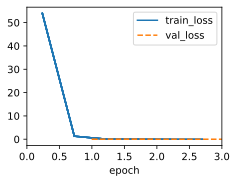

In [57]:
mm=RegressionData1(torch.tensor([2.5,-10.8]),torch.tensor(8.7))
model = LinearRegression1(lr=0.03)
trainer=d2l.Trainer(max_epochs=3)
trainer.fit(model,mm)

# Here is for the weight decay

tensor(0.1422, grad_fn=<DivBackward0>)


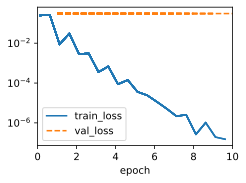

In [58]:
class Data(d2l.DataModule):
    def __init__(self, w,b,noise=0.01,num_train=20,num_test=100,batch_size=5):
        super().__init__()
        self.save_hyperparameters()
        n=self.num_train+self.num_test
        self.X=torch.randn((n,len(w)))
        self.y=torch.matmul(self.X,self.w.reshape(-1,1))+self.b+torch.randn((n,1))*noise
    def get_tensorloader(self, tensors, train, indices=slice(0,None)):
        tensors=tuple(a[indices] for a in tensors)
        dataset=torch.utils.data.TensorDataset(*tensors)
        dataloader=torch.utils.data.DataLoader(dataset,self.batch_size,shuffle=train)
        return dataloader
    def get_dataloader(self, train):
        indices=slice(0,self.num_train) if train else slice(self.num_train,None)
        return self.get_tensorloader((self.X,self.y),train,indices)
class WeightDecayLinearRegression(d2l.Module):
    def __init__(self, lr,lambda_):
        super().__init__()
        self.save_hyperparameters()
        self.net=nn.LazyLinear(1)
        self.net.weight.data.normal_(0,0.01)
        self.net.bias.data.fill_(0.0)
    def loss(self,y_hat,y):
        fn=nn.MSELoss()
        return fn(y_hat,y)+self.lambda_*(self.net.weight**2).sum()/2
    def forward(self,X):
        return self.net(X)
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(),lr=self.lr)
    def get_weight(self):
        print ((self.net.weight**2).sum()/2)
    def get_bias(self):
        print(self.net.bias)
model=WeightDecayLinearRegression(lr=0.01,lambda_=0)
model.board.yscale="log"
mm=Data(w=torch.ones((200,1))*0.01,b=torch.tensor(0.05))
trainer=d2l.Trainer(max_epochs=10)
trainer.fit(model,mm)
model.get_weight()

tensor(0.0137, grad_fn=<DivBackward0>)


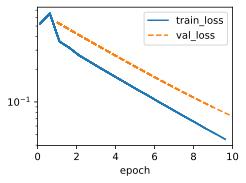

In [59]:
model=WeightDecayLinearRegression(lr=0.01,lambda_=3)
model.board.yscale="log"
mm=Data(w=torch.ones((200,1))*0.01,b=torch.tensor(0.05))
trainer=d2l.Trainer(max_epochs=10)
trainer.fit(model,mm)
model.get_weight()

In [66]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self,wd,lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd=wd
    def configure_optimizers(self):
        return  torch.optim.SGD([{"params":self.net.weight,"weight_decay":self.wd},{"params":self.net.bias}],lr=self.lr)

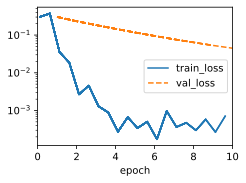

In [67]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, mm)